# Logistic Regression: a simple baseline for predicting match outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score, precision_score, recall_score, classification_report
from matplotlib.ticker import PercentFormatter
from pathlib import Path

### 1. Read the preprocessed data

This notebook reads the preprocessed data directly. The full preprocessing pipeline, consisting of cleaning and feature engineering, is available in `preprocessing.ipynb`.

In [3]:
# Read in the cleaned data.
numeric_dtypes = {
    "Best of": "Int64",
    "Rank_1": "Int64",
    "Rank_2": "Int64",
    "Pts_1": "Int64",
    "Pts_2": "Int64",
    "Odd_1": "Float64",
    "Odd_2": "Float64",
    "Margin": "Float64",
    "Prob_1": "Float64",
    "Prob_2": "Float64",
    "WinRate180_1": "Float64",
    "WinRateLast5_365_1": "Float64",
    "WinRate180_2": "Float64",
}

wta = pd.read_csv(
    "../data/clean_wta.csv",
    dtype=numeric_dtypes,
    parse_dates=["Date"],
    na_values=["", "NA", "N/A", "null", "None", "-"],
    keep_default_na=True,
)

### 2. Create Training, Validation, and Test Sets

As the data form a time series, careful consideration is required when creating the training, validation, and test sets.

Typical strategies, such as random sampling and k-fold cross-validation, may be unsuitable because a model cannot access future data points during training in real-world applications.

For simplicity, I sort the dataset chronologically, using the first 80% of records for training, the subsequent 10% for hyperparameter tuning, and the remaining 10% to assess model performance.

In [4]:
# Create Chronological train(80%)/validation(10%)/test(10%) splits

# Choose date boundaries near 80% and 90% of the wta rows.
validation_start = wta["Date"].iloc[int(len(wta) * 0.8)]
test_start = wta["Date"].iloc[int(len(wta) * 0.9)]

train = wta.loc[wta["Date"] < validation_start].copy() # Train split

validation = wta.loc[(wta["Date"] >= validation_start) & (wta["Date"] < test_start)].copy() # Validation split

test = wta.loc[wta["Date"] >= test_start].copy() # Test split

In [5]:
# Verify that all rows from the dataset are assigned to a set and the date ranges do not overlap between them.

assert len(train) + len(validation) + len(test) == len(wta)

assert train["Date"].max() < validation["Date"].min()

assert validation["Date"].max() < test["Date"].min()

split_summary = pd.DataFrame([
    {
        "Split": name,
        "Rows": len(part),
        "Percent": round(100 * len(part) / len(wta), 2),
        "Start": part["Date"].min(),
        "End": part["Date"].max(),
    }
    for name, part in [
        ("Train", train), ("Validation", validation), ("Test", test)
    ]
])

display(split_summary)

,Split,Rows,Percent,Start,End
0,Train,35667,79.98,2006-12-31,2022-08-16
1,Validation,4464,10.01,2022-08-17,2024-07-16
2,Test,4464,10.01,2024-07-17,2026-06-06


### Create the targets $\hat{y}$.

In [6]:
# Create inputs and targets for the outcome prediction task.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

basic_features = ["Court", "Surface", "Rank_1", "Rank_2"]
basic_features_enhanced = basic_features + ["Margin"]

# Switch to basic_features_enhanced to include bookmaker overround (Margins).
features = basic_features
categorical_features = ["Court", "Surface"]
numeric_features = [name for name in features if name not in categorical_features]

# 1. Impute and standardize numerical inputs; one-hot encode categories.
# Fit every preprocessing step on training data only.
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(
        handle_unknown="ignore", sparse_output=False
    ), categorical_features),
])

X_train = preprocessor.fit_transform(train[features])
X_validation = preprocessor.transform(validation[features])
X_test = preprocessor.transform(test[features])
feature_names = preprocessor.get_feature_names_out()

# 2. Target: 1 = Player 1 wins, 0 = Player 2 wins.
def make_targets(matches):
    valid_winners = (
        matches["Winner"].eq(matches["Player_1"])
        | matches["Winner"].eq(matches["Player_2"])
    )
    if not valid_winners.fillna(False).all():
        raise ValueError("Each Winner must match Player_1 or Player_2.")

    labels = matches["Winner"].eq(matches["Player_1"]).astype("int64")
    return labels.to_numpy()

y_train = make_targets(train)
y_validation = make_targets(validation)
y_test = make_targets(test)

for name, inputs, targets in [
    ("Train", X_train, y_train),
    ("Validation", X_validation, y_validation),
    ("Test", X_test, y_test),
]:
    assert np.isfinite(inputs).all(), f"{name} inputs contain NaN or infinity."
    assert inputs.shape[0] == targets.shape[0]
    print(f"{name}: inputs {tuple(inputs.shape)}, targets {tuple(targets.shape)}")

print("Encoded features:", list(feature_names))

Train: inputs (35667, 9), targets (35667,)
Validation: inputs (4464, 9), targets (4464,)
Test: inputs (4464, 9), targets (4464,)
Encoded features: ['numeric__Rank_1', 'numeric__Rank_2', 'categorical__Court_Indoor', 'categorical__Court_Outdoor', 'categorical__Surface_Carpet', 'categorical__Surface_Clay', 'categorical__Surface_Grass', 'categorical__Surface_Greenset', 'categorical__Surface_Hard']


This is the number of input features for the model:

In [7]:
X_train.shape[1]

9

### 3. Establish Two Baselines for Model Performance Comparisons

I establish two baselines against which to compare each trained model:

1. **Rank-based:** The higher-ranked player is predicted to win.
2. **Bookmaker's pick:** The player assigned the higher *normalized probability* by the bookmaker is predicted to win.

These will help set reasonable expectations for the model performance and provide insight into whether we have learned anything from the data.

In [8]:
# Establish Two Baselines for Metric Comparisons. Ties are resolved simply by choosing Player 1.

# 1. Picking the higher ranked player.
# A smaller rank number means a higher-ranked player.

rank_preds = wta["Player_1"].where(
    wta["Rank_1"] <= wta["Rank_2"],
    wta["Player_2"],
)

# 2. the bookmaker's odds against actual match victory.

bookmaker_prob_preds = wta["Player_1"].where(
    wta["Prob_1"] >= wta["Prob_2"],
    wta["Player_2"],
)

### 4. Define and train the Logistic Regression model

Logistic regression (LR) is a common starting point for classification problems, so it gives a baseline to test the more complex models against. It estimates the probability of a binary outcome (here, Player 1 wins or Player 2 wins) by passing a linear combination of the input features through a sigmoid function.

I use scikit-learn's implementation with L2 regularisation to reduce overfitting, with the penalty parameter set to 1.0. In scikit-learn, `C` is the *inverse* of the regularisation strength, and `C=1.0` is its default.

In [ ]:
lr_model = LogisticRegression(C=1.0)
lr_model.fit(X_train, y_train)

validation_loss = log_loss(y_validation, lr_model.predict_proba(X_validation))
validation_accuracy = accuracy_score(y_validation, lr_model.predict(X_validation))
print(f"Validation loss {validation_loss:.4f}, accuracy {validation_accuracy:.2%}")

Validation loss 0.6692, accuracy 63.44%


In [ ]:
# Use logistic regression on the test set.
lr_test_preds = lr_model.predict(X_test)
lr_test_probabilities = lr_model.predict_proba(X_test)
lr_test_correct = (lr_test_preds == y_test).sum()
lr_test_accuracy = lr_test_correct / len(y_test)

# Class 1 = Player 1 wins; class 0 = Player 2 wins.
test_results = test[["Date", "Player_1", "Player_2", "Winner"]].copy()
test_results["Predicted_class"] = lr_test_preds
test_results["LR_Prob_1"] = lr_test_probabilities[:, 1]
test_results["Predicted_winner"] = test_results["Player_1"].where(
    test_results["Predicted_class"].eq(1), test_results["Player_2"]
)
test_results["Correct"] = test_results["Predicted_winner"].eq(test_results["Winner"])

print(f"Logistic regression test accuracy: {lr_test_accuracy:.2%} "
    f"({lr_test_correct:,}/{len(y_test):,} matches)")

Logistic regression test accuracy: 63.26% (2,824/4,464 matches)


### 5. Analysis and Performance Metrics

We can look at the confusion matrix to see which predictions were correct and which kinds of mistakes the model made.

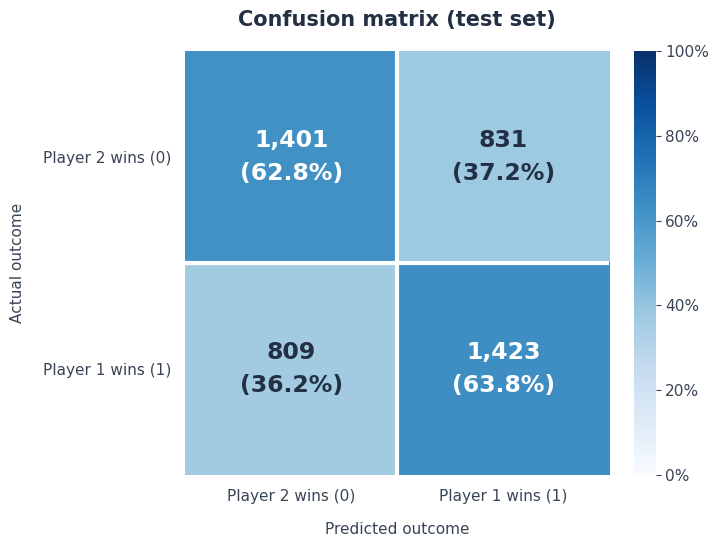

In [11]:
# Make a confusion matrix for the winner prediction task for the logistic regression.
# Evaluate on the held-out test split; rows = actual, columns = predicted.

cm_predictions = lr_model.predict(X_test)
cm_targets = y_test
# Fixed order: class 0 = Player 2 wins, class 1 = Player 1 wins.
cm_counts = confusion_matrix(cm_targets, cm_predictions, labels=[0, 1])
row_totals = cm_counts.sum(axis=1, keepdims=True)
cm_rates = np.divide(
    cm_counts, row_totals,
    out=np.zeros_like(cm_counts, dtype=float), where=row_totals != 0,
)
cm_accuracy = np.trace(cm_counts) / cm_counts.sum()
class_labels = ["Player 2 wins (0)", "Player 1 wins (1)"]

confusion_table = pd.DataFrame(
    cm_counts,
    index=pd.Index(class_labels, name="Actual outcome"),
    columns=pd.Index(class_labels, name="Predicted outcome"),
)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "text.color": "#233044",
    "axes.labelcolor": "#394556",
    "xtick.color": "#394556",
    "ytick.color": "#394556",
    "figure.facecolor": "white",
}):
    confusion_fig, ax = plt.subplots(figsize=(7, 5.6))
    heatmap = ax.imshow(cm_rates, cmap="Blues", vmin=0, vmax=1)

    for row in range(2):
        for col in range(2):
            percentage = f"{cm_rates[row, col]:.1%}" if row_totals[row, 0] else "N/A"
            ax.text(
                col, row, f"{cm_counts[row, col]:,}\n({percentage})",
                ha="center", va="center", fontsize=17, fontweight="bold",
                color="white" if cm_rates[row, col] > 0.55 else "#233044",
                linespacing=1.6,
            )

    ax.set_xticks([0, 1], class_labels)
    ax.set_yticks([0, 1], class_labels)
    ax.set_xlabel("Predicted outcome", labelpad=13)
    ax.set_ylabel("Actual outcome", labelpad=13)
    ax.tick_params(axis="both", length=0, pad=10)
    ax.set_xticks([0.5], minor=True)
    ax.set_yticks([0.5], minor=True)
    ax.grid(which="minor", color="white", linewidth=3)
    ax.tick_params(which="minor", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    colorbar = confusion_fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.05)
    colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    colorbar.outline.set_visible(False)

    ax.set_title("Confusion matrix (test set)", fontsize=15, fontweight="bold", pad=18)
    confusion_fig.tight_layout()
    plt.show()

Recall the two baselines established in Step 3. These provide useful comparisons and insights into the performance of the logistic regression.

In [12]:
rank_accuracy = rank_preds.loc[test.index].eq(test["Winner"]).mean()
bookmaker_accuracy = bookmaker_prob_preds.loc[test.index].eq(test["Winner"]).mean()
rank_accuracy_train = rank_preds.loc[train.index].eq(train["Winner"]).mean()
bookmaker_accuracy_train = bookmaker_prob_preds.loc[train.index].eq(train["Winner"]).mean()

print(f"Rank baseline accuracy (test/train splits): {rank_accuracy:.2%}, {rank_accuracy_train:.2%}")
print(f"Bookmaker baseline accuracy (test/train splits): {bookmaker_accuracy:.2%}, {bookmaker_accuracy_train:.2%}")

Rank baseline accuracy (test/train splits): 63.13%, 65.49%
Bookmaker baseline accuracy (test/train splits): 68.62%, 69.26%


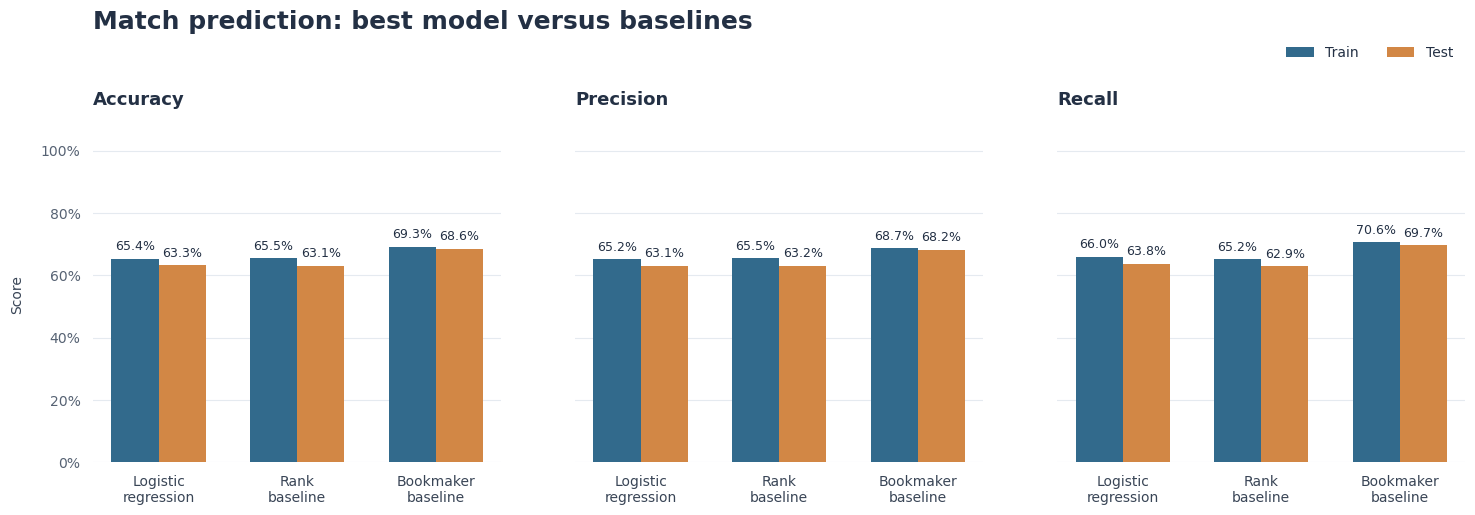

,Model,Split,Matches,Accuracy,Precision,Recall
0,Logistic regression,Train,"35,667",65.41%,65.21%,66.00%
1,Rank baseline,Train,"35,667",65.49%,65.55%,65.22%
2,Bookmaker baseline,Train,"35,667",69.26%,68.74%,70.59%
3,Logistic regression,Test,"4,464",63.26%,63.13%,63.75%
4,Rank baseline,Test,"4,464",63.13%,63.17%,62.95%
5,Bookmaker baseline,Test,"4,464",68.62%,68.23%,69.67%


In [13]:
# Compare train/test accuracy, precision and recall for the logistic regression and baselines.
# These are grouped bar charts: each bar summarises a classification metric.

metric_rows = []

for split_name, matches, inputs, targets in [
    ("Train", train, X_train, y_train),
    ("Test", test, X_test, y_test),
]:
    actual = matches["Winner"].eq(matches["Player_1"]).astype(int).to_numpy()
    assert np.array_equal(actual, targets)

    lr_predictions = lr_model.predict(inputs)

    if matches[["Rank_1", "Rank_2", "Prob_1", "Prob_2"]].isna().any().any():
        raise ValueError("Baseline inputs must be present for every evaluated match.")

    predictions = {
        "Logistic regression": lr_predictions,
        # Match the existing baselines: choose Player 1 when tied.
        "Rank baseline": matches["Rank_1"].le(matches["Rank_2"]).astype(int).to_numpy(),
        "Bookmaker baseline": matches["Prob_1"].ge(matches["Prob_2"]).astype(int).to_numpy(),
    }

    for model_name, predicted in predictions.items():
        metric_rows.append({
            "Model": model_name,
            "Split": split_name,
            "Matches": len(actual),
            "Accuracy": accuracy_score(actual, predicted),
            "Precision": precision_score(actual, predicted, pos_label=1, zero_division=0),
            "Recall": recall_score(actual, predicted, pos_label=1, zero_division=0),
        })

comparison_metrics = pd.DataFrame(metric_rows)
model_order = ["Logistic regression", "Rank baseline", "Bookmaker baseline"]
model_labels = ["Logistic\nregression", "Rank\nbaseline", "Bookmaker\nbaseline"]
split_colors = {"Train": "#326A8C", "Test": "#D28745"}

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#394556",
    "text.color": "#233044",
    "xtick.color": "#394556",
    "ytick.color": "#566273",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}):
    comparison_fig, axes = plt.subplots(1, 3, figsize=(15, 5.8), sharey=True)
    x = np.arange(len(model_order))
    width = 0.34

    for ax, metric in zip(axes, ["Accuracy", "Precision", "Recall"]):
        for split_name, offset in [("Train", -width / 2), ("Test", width / 2)]:
            values = (
                comparison_metrics.loc[comparison_metrics["Split"].eq(split_name)]
                .set_index("Model")
                .loc[model_order, metric]
                .to_numpy() * 100
            )
            bars = ax.bar(
                x + offset, values, width=width,
                color=split_colors[split_name], label=split_name, zorder=3,
            )
            ax.bar_label(
                bars, labels=[f"{value:.1f}%" for value in values],
                padding=4, fontsize=9, color="#233044",
            )

        ax.set_title(metric, loc="left", pad=15)
        ax.set_xticks(x, model_labels)
        ax.set_ylim(0, 108)  # Space above 100% for value labels.
        ax.set_yticks(np.arange(0, 101, 20))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.grid(axis="y", color="#E5EAF0", linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", length=0, pad=9)
        for spine in ax.spines.values():
            spine.set_visible(False)

    axes[0].set_ylabel("Score", labelpad=12)
    comparison_fig.suptitle(
        "Match prediction: best model versus baselines",
        x=0.07, y=0.97, ha="left", fontsize=18, fontweight="bold",
    )
    handles, labels = axes[0].get_legend_handles_labels()
    comparison_fig.legend(
        handles, labels, loc="upper right", bbox_to_anchor=(0.985, 0.93),
        ncol=2, frameon=False,
    )

    comparison_fig.subplots_adjust(
        left=0.07, right=0.985, top=0.77, bottom=0.19, wspace=0.18
    )
    plt.show()

# Exact metric values remain available for reporting.
display(comparison_metrics.style.format({
    "Matches": "{:,}",
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
}))

I save the test-set metrics to output/summary.csv to compare the logistic regression with the other models.

In [ ]:
# Save test-set metrics for the logistic regression to output/summary.csv.

summary_predictions = {"logistic_regression": cm_predictions}

summary = pd.DataFrame([
    {
        "model": model_name,
        "precision": precision_score(cm_targets, predicted, zero_division=0),
        "recall": recall_score(cm_targets, predicted, zero_division=0),
        "f1": f1_score(cm_targets, predicted, zero_division=0),
        "accuracy": accuracy_score(cm_targets, predicted),
    }
    for model_name, predicted in summary_predictions.items()
])

project_root = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
summary_path = project_root / "output" / "summary.csv"
summary_path.parent.mkdir(exist_ok=True)

# Keep other models' rows; replace a model's row only when it is saved again.
if summary_path.exists():
    saved = pd.read_csv(summary_path)
    summary = pd.concat([saved[~saved["model"].isin(summary["model"])], summary])
summary.to_csv(summary_path, index=False, float_format="%.4f")

### 6. Export the Model for Inference Without Retraining

In [ ]:
# import joblib

In [ ]:
# project_root = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
# export_path = project_root / "models" / "logistic_regression"
# export_path.mkdir(parents=True, exist_ok=True)

# joblib.dump(lr_model, export_path / "model.joblib")

# preprocessing_artifact = {
#     "preprocessor": preprocessor,
#     "features": features,
#     "feature_names": list(feature_names),
# }
# joblib.dump(preprocessing_artifact, export_path / "preprocessing.joblib")

# print("Saved model and preprocessing to:", export_path)

Saved model and preprocessing to: /Users/girlenginerd/Desktop/sheff/private_projects/break/agents/aecom_hw_test/models/logistic_regression
